In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import chi2_contingency, chi2
from scipy.stats import ttest_ind  
import scipy.stats as ss

In [4]:
data = pd.read_csv('dating_data.csv')
data.head()

,user_id_1,user_id_2,group,is_match
0,79,91,1,1
1,716,353,1,1
2,423,677,0,0
3,658,165,1,1
4,969,155,0,1


In [5]:
#пропущенных значений нет
data.isna().sum()

user_id_1    0
user_id_2    0
group        0
is_match     0
dtype: int64

In [6]:
#пользователи первой группы
group1_list = list(set(data.query("group == 1").user_id_1.tolist() + (data.query("group == 1").user_id_2.tolist())))
len(group1_list)

499

In [7]:
#пользователи второй группы
group0_list = list(set(data.query("group == 0").user_id_1.tolist() + (data.query("group == 0").user_id_2.tolist())))
len(group0_list)

501

In [8]:
#проверим, есть ли пользователи, которые попали одновременны в обе группы
#таких пользователей нет
np.intersect1d(group0_list, group1_list)

array([], dtype=int64)

<hr>

Для начала проверим, есть ли взаимосвязь между количеством мэтчей и применением нового алгоритма

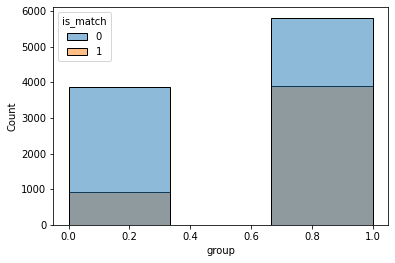

In [18]:
#кажется новый алгоритм работает лучше
sns.histplot(data=data, x='group', hue='is_match', bins=3)

Из графика видно, что в группе с использованием нового алгоритма мэтч случался чаще (примерно 40%), чем в группе со старым алгоритмом (примерно 20%).

Нужно понять, является ли это различие статистически значимым. 

H1 - частота мэтчей зависит от группы (использование нового алгоритма увеличило частоту мэтчей)

H0 - частота мэтчей не зависит от группы (новый алгоритм никак не повлиял на частоту мэтчей)

Для этого используем Критерий Хи-квадрат

In [10]:
pd.crosstab(data.is_match, data.group)

group,0,1
is_match,,
0,3858,5813
1,934,3909


In [11]:
stat, p, dof, expected = chi2_contingency(pd.crosstab(data.is_match, data.group))
stat, p

(618.6889141576197, 1.441829916366341e-136)

p-value < 0,05 - опровергаем нулевую гипотезу - следовательно различия статистически значимые.

Мы с уверенностью можем говорить, что при использовании нового алгоритма мэтчи происходят чаще

<hr>

Теперь посмотрим как в среднем меняется конверсия у пользователей

In [4]:
#конверсия для пользователей из группы 0
a = data.query("group == 0")[['user_id_1', 'is_match']].rename(columns={'user_id_1': 'user_id'})
b = data.query("group == 0")[['user_id_2', 'is_match']].rename(columns={'user_id_2': 'user_id'})
group0 = a.append(b)
convers0 = group0.groupby('user_id', as_index=False).agg({'is_match': 'mean'})

NameError: name 'data' is not defined

In [13]:
#конверсия для пользователей из группы 1
a = data.query("group == 1")[['user_id_1', 'is_match']].rename(columns={'user_id_1': 'user_id'})
b = data.query("group == 1")[['user_id_2', 'is_match']].rename(columns={'user_id_2': 'user_id'})
group1 = a.append(b)
convers1 = group1.groupby('user_id', as_index=False).agg({'is_match': 'mean'})

/opt/tljh/user/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/tljh/user/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


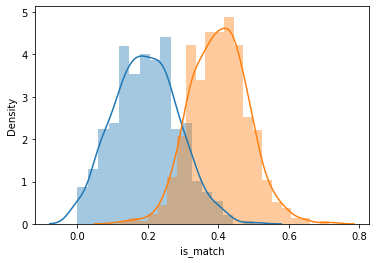

In [14]:
sns.distplot(convers0.is_match)
sns.distplot(convers1.is_match)

На графике видны различия, средняя конверсия у пользователей группы 1 больше средней конверсии пользователей группы 2.

Нужно понять, являются ли эти различия статистически значимыми.

H1 - средняя конверсия метчей зависит от группы (использование нового алгоритма увеличило среднюю конверсию мэтчей)

H0 - средняя конверсия метчей не зависит от группы (новый алгоритм никак не повлиял на среднюю конверсию мэтчей)

Оба распределения являются нормальными, не имеют экстиральных выбросов поэтому я буду использовать двухвыботочный t-тест

In [2]:
ss.ttest_ind(convers0.is_match, convers1.is_match)

NameError: name 'convers0' is not defined

p-value < 0.05 - отклоняем нулевую гипотезу - следовательно различия между средними значаниями конверсии в двух группах статистически значимы

**Я делаю вывод что новый алгоритм работает лучше старого.**

In [3]:
convers0

NameError: name 'convers0' is not defined